#📌 Extracción

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
ruta = "https://raw.githubusercontent.com/paros/Challenge-Telecom-X-Parte-1/main/TelecomX_Data.json"
df = pd.read_json(ruta)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [5]:
columnas = list(df.columns)
cols = columnas[2:]

In [6]:
df2 = pd.concat(
    [df.drop(cols, axis=1),
     pd.json_normalize(df[cols].to_dict(orient='records'))],
    axis=1
)
df2.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [7]:
columnas2 = list(df2.columns)
columnas2

['customerID',
 'Churn',
 'customer.gender',
 'customer.SeniorCitizen',
 'customer.Partner',
 'customer.Dependents',
 'customer.tenure',
 'phone.PhoneService',
 'phone.MultipleLines',
 'internet.InternetService',
 'internet.OnlineSecurity',
 'internet.OnlineBackup',
 'internet.DeviceProtection',
 'internet.TechSupport',
 'internet.StreamingTV',
 'internet.StreamingMovies',
 'account.Contract',
 'account.PaperlessBilling',
 'account.PaymentMethod',
 'account.Charges.Monthly',
 'account.Charges.Total']

In [8]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

**Verificación de Valores únicos.**

In [ ]:
#Verificacion valores unicos
for col in df2.columns:
  print(f"valores unicos en la columna'{col}:{df2[col].nunique()}'")

  if df2[col].nunique() < 50:
    print(df2[col].unique())
    print('-'*50)

valores unicos en la columna'customerID:7267'
valores unicos en la columna'Churn:3'
['No' 'Yes' '']
--------------------------------------------------
valores unicos en la columna'customer.gender:2'
['Female' 'Male']
--------------------------------------------------
valores unicos en la columna'customer.SeniorCitizen:2'
[0 1]
--------------------------------------------------
valores unicos en la columna'customer.Partner:2'
['Yes' 'No']
--------------------------------------------------
valores unicos en la columna'customer.Dependents:2'
['Yes' 'No']
--------------------------------------------------
valores unicos en la columna'customer.tenure:73'
valores unicos en la columna'phone.PhoneService:2'
['Yes' 'No']
--------------------------------------------------
valores unicos en la columna'phone.MultipleLines:3'
['No' 'Yes' 'No phone service']
--------------------------------------------------
valores unicos en la columna'internet.InternetService:3'
['DSL' 'Fiber optic' 'No']
--------

**Verificación valores duplicados**

In [9]:
#Verificacion valores duplicados
print('numero de duplicados', df2.duplicated().sum())

numero de duplicados 0


**Verificación valores nulos**

In [14]:
#verificacion valores nulos
print('Números nulos', df.isnull().sum())

df2.isnull().sum()

Números nulos customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64


,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


**Verificación valores en blanco**

In [13]:
#Verificacion valores en blanco
df2.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


1. Cambiando la columna "account.Charges.Total" a Float

In [15]:
df2['account.Charges.Total'] = pd.to_numeric(df2['account.Charges.Total'], errors='coerce')


In [21]:
df2= df2[df2['Churn'].str.strip() != '']
print("Número de filas después de eliminar las vacías en 'Churn':", len(df))

df2.info()


Número de filas después de eliminar las vacías en 'Churn': 7267
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   object 
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   object 
 5   customer.Dependents        7032 non-null   object 
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   object 
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   ob

Verificacion de vacios o en blanco

In [22]:
df2.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [23]:
df2 = df2.dropna(subset=['account.Charges.Total'])

In [24]:
print("Numero de Nulos \n", df2.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [25]:
df2.to_csv('TelecomX_Data.csv', index=False)

In [26]:
df2['cuentas_diarias'] = df2['account.Charges.Monthly'] / 30
df2

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [27]:
## Cambio de nombre de las columnas
columnas = {                                                        # Diccionario con los nuevos nombres de las columnas.
    'customerID': 'id_cliente',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'adulto +60',
    'customer.Partner': 'posee_pareja',
    'customer.Dependents': 'posee_dependientes',
    'customer.tenure': 'tiempo_contrato',
    'phone.PhoneService': 'servicio_telefono',
    'phone.MultipleLines': 'multiples_lineas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguridad_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'proteccion_dispositivo',
    'internet.TechSupport': 'soporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_peliculas',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'factura_digital',
    'account.PaymentMethod': 'metodo_pago',
    'account.Charges.Monthly': 'valor_mensual',
    'account.Charges.Total': 'cobro_total'
}
df2 = df2.rename(columns= columnas)
df2

,id_cliente,Churn,genero,adulto +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,cobro_total,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [28]:
df2['Churn'] = df2['Churn'].replace({'No': 'No', 'Yes': 'Sí'})
df2['genero'] = df2['genero'].replace({'Female': 'Femenino', 'Male': 'Masculino'})
df2['posee_pareja'] = df2['posee_pareja'].replace({'Yes': 'Sí', 'No': 'No'})
df2['posee_dependientes'] = df2['posee_dependientes'].replace({'Yes': 'Sí', 'No': 'No'})
df2['servicio_telefono'] = df2['servicio_telefono'].replace({'Yes': 'Sí', 'No': 'No'})
df2['multiples_lineas'] = df2['multiples_lineas'].replace({'No': 'No', 'Yes': 'Sí', 'No phone service': 'Sin servicio de teléfono'})
df2['tipo_internet'] = df2['tipo_internet'].replace({'No': 'No'})
df2['tipo_contrato'] = df2['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensual', 'Two year': 'Bienal'})
df2.head()


,id_cliente,Churn,genero,adulto +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,cobro_total,cuentas_diarias
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,...,No,Yes,Yes,No,Anual,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,...,No,No,No,Yes,Mensual,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,...,Yes,No,No,No,Mensual,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,...,Yes,No,Yes,Yes,Mensual,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,...,No,Yes,Yes,No,Mensual,Yes,Mailed check,83.9,267.40,2.796667


In [29]:
columnas_a_traducir = ['seguridad_online', 'backup_online', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas']
mapeo = {'No': 'No', 'Yes': 'Sí', 'No internet service': 'Sin servicio de internet'}

for col in columnas_a_traducir:
    df2[col] = df2[col].replace(mapeo)

df2.head()

,id_cliente,Churn,genero,adulto +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,cobro_total,cuentas_diarias
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,...,No,Sí,Sí,No,Anual,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,...,No,No,No,Sí,Mensual,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,...,Sí,No,No,No,Mensual,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,...,Sí,No,Sí,Sí,Mensual,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,...,No,Sí,Sí,No,Mensual,Yes,Mailed check,83.9,267.40,2.796667


In [34]:
df2['metodo_pago'] = df2['metodo_pago'].replace({
    'Mailed check': 'Cheque enviado por correo',
    'Electronic check': 'Cheque electrónico',
    'Credit card (automatic)': 'Tarjeta de crédito (automático)',
    'Bank transfer (automatic)': 'Transferencia bancaria (automática)'
})
df2.head()

,id_cliente,Churn,genero,adulto +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,cobro_total,cuentas_diarias
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,...,No,Sí,Sí,No,Anual,Yes,Cheque enviado por correo,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,...,No,No,No,Sí,Mensual,No,Cheque enviado por correo,59.9,542.40,1.996667
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,...,Sí,No,No,No,Mensual,Yes,Cheque electrónico,73.9,280.85,2.463333
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,...,Sí,No,Sí,Sí,Mensual,Yes,Cheque electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,...,No,Sí,Sí,No,Mensual,Yes,Cheque enviado por correo,83.9,267.40,2.796667


In [36]:
df2['adulto +60'] = df2['adulto +60'].replace({1:'Si', 0:'No'})
df2.head()

,id_cliente,Churn,genero,adulto +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,cobro_total,cuentas_diarias
0,0002-ORFBO,No,Femenino,No,Sí,Sí,9,Sí,No,DSL,...,No,Sí,Sí,No,Anual,Yes,Cheque enviado por correo,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,No,No,No,9,Sí,Sí,DSL,...,No,No,No,Sí,Mensual,No,Cheque enviado por correo,59.9,542.40,1.996667
2,0004-TLHLJ,Sí,Masculino,No,No,No,4,Sí,No,Fiber optic,...,Sí,No,No,No,Mensual,Yes,Cheque electrónico,73.9,280.85,2.463333
3,0011-IGKFF,Sí,Masculino,Si,Sí,No,13,Sí,No,Fiber optic,...,Sí,No,Sí,Sí,Mensual,Yes,Cheque electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,Sí,Femenino,Si,Sí,No,3,Sí,No,Fiber optic,...,No,Sí,Sí,No,Mensual,Yes,Cheque enviado por correo,83.9,267.40,2.796667


#📊 Carga y análisis

In [37]:
df2.describe()

,tiempo_contrato,valor_mensual,cobro_total,cuentas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,2.159940
std,24.545260,30.085974,2266.771362,1.002866
min,1.000000,18.250000,18.800000,0.608333
25%,9.000000,35.587500,401.450000,1.186250
50%,29.000000,70.350000,1397.475000,2.345000
75%,55.000000,89.862500,3794.737500,2.995417
max,72.000000,118.750000,8684.800000,3.958333


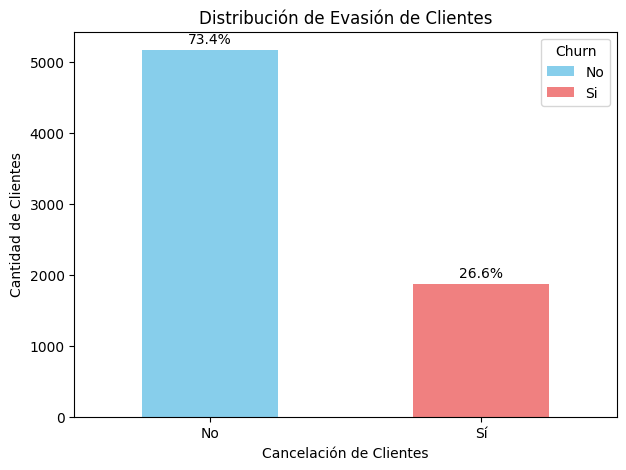

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
churn_counts = df2['Churn'].value_counts()
churn_percentages = (churn_counts / len(df2)) * 100

ax = churn_counts.plot(kind='bar',  color=['skyblue','lightcoral'])
plt.title('Distribución de Evasión de Clientes')
plt.xlabel('Cancelación de Clientes')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)


for i, percentage in enumerate(churn_percentages):
    ax.text(i, churn_counts.iloc[i] + 50, f'{percentage:.1f}%', ha='center', va='bottom')
ax.legend(handles=legend_elements, title="Churn")

plt.show()

In [60]:
import plotly.express as px

In [70]:
px.histogram(df2, x = 'genero', text_auto = True, color = 'Churn', barmode = 'group')



In [71]:
px.histogram(df2, x = 'tiempo_contrato', text_auto = True, color = 'Churn', barmode = 'group')

De la Gráfica es posible apreciar que la mayor tasa de abandono ocurre durante el primer mes. Estabilizándose al año.

In [72]:
px.histogram(df2, x = 'tipo_contrato', text_auto = True, color = 'Churn', barmode = 'group')


Detalle Contrato se observa:

El Contrato Anual: posee 1,472 clientes y presenta un abandono de Clientes de 166, que representa el 11.28%

El Contrato Mensual: es el que más Clientes posee con 3,875 contratos, con un abandono de clientes de un 42.71%.

El Contrato Bienal: posee 1685 clientes y un abandono de 48 clientes, que representa 2.85%

Los Clientes que tuvieron contrato Mensual, fueron los que más abandonaron contrato con la empresa Telecomx

In [73]:
px.histogram(df2, x = 'tipo_internet',  text_auto = True, color = 'Churn', barmode = 'group')

Este gráfico nos muestra que los clientes que tenían Fiber Optic, fueron los que más abandono presentan.

El servicio Fiber Optic posee 3096 Clientes de los cuales 1297 abandonaron el servicio lo que representa un 41.89%.


In [74]:
px.histogram(df2, x = 'metodo_pago',  text_auto = True, color = 'Churn', barmode = 'group')

Del gráfico es posible observar que los clientes que tienen el método de Pago con Cheque Electrónico son los que más han abandonaron el servicio con la empresa TelecomX

In [75]:
px.histogram(df2, x = 'adulto +60',  text_auto = True, color = 'Churn', barmode = 'group')

Del rango etario podemos observar que:

Adulto Mayor (mayor 65 años): posee 1,142 clientes, de los cuales presenta un abandono de clientes de 476, que representa el 41.68%

Adulto (menor a 65 años): posee 5,890 Clientes, de los cuales presenta un abandono de Clientes de 1,393 que representa el 23.65%.

Es posible concluir que el grupo de adultos mayores muestra casi el doble de probabilidad de abandono en comparación con los menores de 65 años.

#📄Informe final

### 🔹 Introducción

La empresa Telecom X, es una empresa que ofrece servicios de Telecomunicacion, y enfrenta una tasa significativa de abandono de clientes (churn), lo que impacta directamente sus ingresos recurrentes.

El objetivo del estudio es identificar los factores que influyen en la evasión de clientes a partir de un dataset de 7,043 usuarios que cuenta con datos relevantes de la empresa.

### 🔹 Limpieza y Tratamiento de Datos

1.- Primero se realizó la lectura de los datos en formato .json

2.- Una vez disponible los datos, estos fueron normalizados.

3.- Se realizó la limpieza de datos, mediante la verificación de valores vacios o en blanco, para ser reemplazados a valores nulos y finalmente eliminados.

4.- Se realizó la estandarización y normalización del dataset, traduciendo las variables categóricas y renombrando las columnas para garantizar consistencia.

###🔹 Análisis Exploratorio de Datos

##### **1.-Deserción Total**

Podemos observar que el porcentaje de Clientes que dejaron la Empresa Telecomx es de un 26,58%, lo que significa que aproximadamente 1 de cada 4 clientes cancela el servicio.
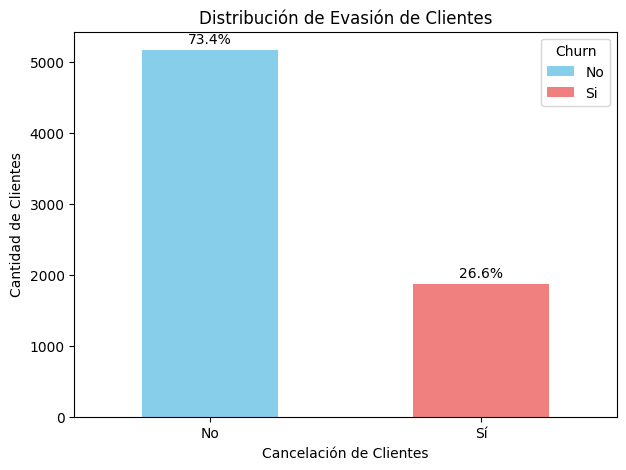


##### **2.- Antigüedad del Cliente**

La antigüedad es uno de los factores más importantes.

- Clientes con menos de 12 meses presentan el mayor riesgo.

- El período más crítico son los primeros 6 meses.

- Clientes con más de 24 meses muestran mayor fidelidad.


##### **3.-Tipo de Contrato**

El tipo de contrato tiene una fuerte relación con el abandono de los clientes;

El Contrato Anual: posee 1,472 clientes y presenta un abandono de Clientes de 166, que representa el 11.28%

El Contrato Mensual: es el que más Clientes posee con 3,875 contratos, con un abandono de clientes de un 42.71%.

El Contrato Bienal: posee 1685 clientes y un abandono de 48 clientes, que representa 2.85%

Se puede concluir que los Clientes que tuvieron contrato Mensual, fueron los que más abandonaron contrato con la empresa Telecomx.


##### **4.- Método de Pago**

El método de pago influye en la retención.

El método de Pago con Cheque Electrónico tiene la mayor tasa de abandono; y aquellos con Pagos automáticos tienen menor churn.


##### **5.- Factores Demográficos**

Del rango etario podemos observar que:

Adulto Mayor (mayor 65 años): posee 1,142 clientes, de los cuales presenta un abandono de clientes de 476, que representa el 41.68%

Adulto (menor a 65 años): posee 5,890 Clientes, de los cuales presenta un abandono de Clientes de 1,393 que representa el 23.65%.

Es posible concluir que el grupo de adultos mayores muestra casi el doble de probabilidad de abandono en comparación con los menores de 65 años.

### 🔹 Principales hallazgos y conclusiones

El análisis del churn en TelecomX evidencia que el abandono de clientes se asocia a características relacionadas con el tipo de contrato, el método de pago, el tipo de servicio y el perfil del cliente.

En particular, los clientes con contrato mensual presentan una mayor tendencia a cancelar el servicio, lo que sugiere que la ausencia de compromisos de largo plazo aumenta la probabilidad de abandono ante insatisfacción o la aparición de mejores ofertas en el mercado.

También es posible observa, una mayor deserción entre los usuarios del servicio de fibra óptica y entre quienes utilizan cheque electrónico como método de pago.

Por otra parte, el churn se concentra especialmente en clientes nuevos, lo que indica que los primeros meses de relación con la empresa son un periodo crítico para la fidelización.

En relación con el factor etario, los adultos mayores presentan una mayor tasa proporcional de abandono, aunque en términos absolutos la mayor cantidad de cancelaciones proviene del grupo de clientes menores de 65 años, debido a que este segmento es considerablemente más amplio dentro de la base de clientes.

**Conclusiones:**

Se sugiere fortalecer las estrategias de retención durante los primeros meses y mejorar el valor percibido del servicio podrían contribuir significativamente a reducir la evasión de clientes.  Tambien se sugiere incentivar pagos automáticos Reducir el uso de electronic check

### 🔹 Recomendaciones

1. Fortalecer la experiencia inicial del cliente
Dado que el abandono se concentra en los primeros meses, es fundamental reforzar las estrategias de acompañamiento y fidelización durante la etapa inicial de la relación con el cliente, asegurando que comprenda el funcionamiento del servicio y perciba valor desde el comienzo.


2. Incentivar métodos de pago y contratos de mayor estabilidad
Se recomienda promover métodos de pago automáticos y modalidades de contratación de mayor duración, ya que estos mecanismos pueden contribuir a reducir la fricción en el proceso de pago y aumentar la permanencia de los clientes.